In [39]:
import torch
from torch import nn, optim
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

In [15]:
Training_datasets = datasets.FashionMNIST (
    root = "data" , 
    train = True , 
    download = True , 
    transform = ToTensor()
) 

test_data = datasets.FashionMNIST (
    root = "true" ,
    train = True , 
    download = True , 
    transform = ToTensor()
)

100%|█████████████████████████████████████| 26.4M/26.4M [00:13<00:00, 1.96MB/s]
100%|██████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 128kB/s]
100%|█████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 1.65MB/s]
100%|█████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 5.72MB/s]


In [19]:
batch_size = 64 
train_loader = DataLoader(Training_datasets , batch_size = batch_size)
test_loader = DataLoader(test_data , batch_size = batch_size)  

for images , labels in train_loader :
    print(images.shape , labels.shape)
    break 

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [21]:
labels[0]

tensor(9)

In [22]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

classes[labels[7].item()]

'Pullover'

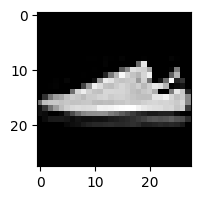

In [28]:
plt.figure(figsize=(2,2))
plt.imshow(images[6].cpu().squeeze() , cmap = 'gray')
plt.show()

### Build Neural Network 

In [29]:
device = "cpu"


In [46]:
class ClothesClassifier(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28 ,128) ,
            nn.ReLU(),
            nn.Linear(128 , 64) ,
            nn.ReLU(),
            nn.Linear(64 , 10)
        )

        
    def forward(self , x ) :
        return self.network(x)
    
        

In [51]:
model = ClothesClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)





In [57]:
epochs = 2

model.train()

for epoch in range(epochs):
    for batch, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        pred = model(images)
        loss = loss_fn(pred, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
        if batch % 100 == 0:
            print(f"Batch: {batch}, Loss: {loss.item()}")

Batch: 0, Loss: 1.6184372901916504
Batch: 100, Loss: 1.564387559890747
Batch: 200, Loss: 1.431120753288269
Batch: 300, Loss: 1.4886538982391357
Batch: 400, Loss: 1.3952629566192627
Batch: 500, Loss: 1.3799582719802856
Batch: 600, Loss: 1.386164903640747
Batch: 700, Loss: 1.3082383871078491
Batch: 800, Loss: 1.3703306913375854
Batch: 900, Loss: 1.2554271221160889
Batch: 0, Loss: 1.3849997520446777
Batch: 100, Loss: 1.3457045555114746
Batch: 200, Loss: 1.1910680532455444
Batch: 300, Loss: 1.2764649391174316
Batch: 400, Loss: 1.1726207733154297
Batch: 500, Loss: 1.1918394565582275
Batch: 600, Loss: 1.1973507404327393
Batch: 700, Loss: 1.1342976093292236
Batch: 800, Loss: 1.185701847076416
Batch: 900, Loss: 1.0983167886734009


### Test the model 

model.eval() 
all_prediction = []
all_labels = []

with torch.no_grad() :
    for images ,labels in test_loader : 
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        _, predicted= torch.max(output.data ,1 )

        # append labels and predictions to lists 
        all_labels.extend(labels.cpu().numpy())
        all_prediction.extend(predicted.cpu().numpy())
        

In [68]:
from sklearn.metrics import classification_report

report = classification_report(all_labels , all_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.64      0.80      0.71      6000
           1       0.82      0.91      0.86      6000
           2       0.54      0.59      0.57      6000
           3       0.66      0.67      0.66      6000
           4       0.41      0.61      0.49      6000
           5       0.94      0.01      0.03      6000
           6       0.40      0.03      0.05      6000
           7       0.60      0.89      0.71      6000
           8       0.86      0.89      0.88      6000
           9       0.63      0.93      0.75      6000

    accuracy                           0.63     60000
   macro avg       0.65      0.63      0.57     60000
weighted avg       0.65      0.63      0.57     60000



### optimizer with momentum 

In [76]:
optimizer_momentum = optim.SGD(model.parameters(), lr=0.001 , momentum=0.9)


In [77]:
epochs = 2

model.train()

for epoch in range(epochs):
    for batch, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        pred = model(images)
        loss = loss_fn(pred, labels)
        
        loss.backward()
        optimizer_momentum.step()
        optimizer_momentum.zero_grad()
    
        if batch % 100 == 0:
            print(f"Batch: {batch}, Loss: {loss.item()}")

Batch: 0, Loss: 0.542944073677063
Batch: 100, Loss: 0.6669033169746399
Batch: 200, Loss: 0.4287925362586975
Batch: 300, Loss: 0.6621228456497192
Batch: 400, Loss: 0.6471037864685059
Batch: 500, Loss: 0.5733354687690735
Batch: 600, Loss: 0.596149742603302
Batch: 700, Loss: 0.659248948097229
Batch: 800, Loss: 0.6433029770851135
Batch: 900, Loss: 0.5399569869041443
Batch: 0, Loss: 0.4659278094768524
Batch: 100, Loss: 0.6023054122924805
Batch: 200, Loss: 0.3747255802154541
Batch: 300, Loss: 0.6107789874076843
Batch: 400, Loss: 0.6039907336235046
Batch: 500, Loss: 0.5351483225822449
Batch: 600, Loss: 0.5435879230499268
Batch: 700, Loss: 0.6535216569900513
Batch: 800, Loss: 0.6390853524208069
Batch: 900, Loss: 0.48867130279541016


In [85]:
model.eval() 

all_pred = []
all_labels = [] 

with torch.no_grad() :
    for images , labels in test_loader :
        images = images.to(device)
        labels = labels.to(device) 

        output = model(images)

        _ , predicted = torch.max(output.data ,1 )

        # append all the pred and lables 
        all_labels.extend(labels.cpu().numpy())
        all_pred.extend(predicted.cpu().numpy())

In [86]:
from sklearn.metrics import classification_report

report = classification_report( all_labels, all_pred)
print(report)

              precision    recall  f1-score   support

           0       0.72      0.86      0.78      6000
           1       0.97      0.95      0.96      6000
           2       0.78      0.64      0.70      6000
           3       0.82      0.86      0.84      6000
           4       0.67      0.82      0.74      6000
           5       0.93      0.89      0.91      6000
           6       0.60      0.43      0.50      6000
           7       0.89      0.88      0.88      6000
           8       0.92      0.95      0.93      6000
           9       0.89      0.94      0.92      6000

    accuracy                           0.82     60000
   macro avg       0.82      0.82      0.82     60000
weighted avg       0.82      0.82      0.82     60000



### optimizer with Adam 

In [89]:
optimizer_adam = optim.Adam(model.parameters() , lr=0.001)

In [99]:
epochos = 2 
model.train() 

for epoch in range(epochos) :
    for batch ,(images , labels ) in enumerate (train_loader) :
        images = images.to(device)
        lables = labels.to(device) 

        pred = model(images)
        loss = loss_fn(pred, labels)

        loss.backward()
        optimizer_adam.step()
        optimizer_adam.zero_grad() 

        if batch % 100 == 0:
            print(f"Batch: {batch}, Loss: {loss.item()}")

Batch: 0, Loss: 0.4090888798236847
Batch: 100, Loss: 0.5288746356964111
Batch: 200, Loss: 0.37866172194480896
Batch: 300, Loss: 0.5478889346122742
Batch: 400, Loss: 0.4827304482460022
Batch: 500, Loss: 0.4482380449771881
Batch: 600, Loss: 0.38652363419532776
Batch: 700, Loss: 0.5845838189125061
Batch: 800, Loss: 0.5034975409507751
Batch: 900, Loss: 0.5386438965797424
Batch: 0, Loss: 0.25756388902664185
Batch: 100, Loss: 0.405690997838974
Batch: 200, Loss: 0.29391875863075256
Batch: 300, Loss: 0.42072010040283203
Batch: 400, Loss: 0.4074053168296814
Batch: 500, Loss: 0.38921770453453064
Batch: 600, Loss: 0.3467775285243988
Batch: 700, Loss: 0.48235389590263367
Batch: 800, Loss: 0.4490184485912323
Batch: 900, Loss: 0.46525269746780396


In [112]:
model.eval() 

all_pred = []
all_labels = []

with torch.no_grad() :
    for images , labels in test_loader :
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        _,prediction = torch.max(output.data , 1 )

        # append all the pred and labels 
        all_labels.extend(labels.cpu().numpy())
        all_pred.extend(prediction.cpu().numpy())
        
        

In [113]:
report = classification_report(all_labels , all_pred)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.86      0.83      6000
           1       0.98      0.98      0.98      6000
           2       0.87      0.63      0.73      6000
           3       0.87      0.89      0.88      6000
           4       0.66      0.91      0.76      6000
           5       0.96      0.96      0.96      6000
           6       0.76      0.60      0.67      6000
           7       0.91      0.97      0.94      6000
           8       0.96      0.98      0.97      6000
           9       0.98      0.92      0.95      6000

    accuracy                           0.87     60000
   macro avg       0.88      0.87      0.87     60000
weighted avg       0.88      0.87      0.87     60000

